In [1]:
!pip install kaggle



In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp /Users/harshitdubey/Downloads/kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#Importing Face Mask Dataset
## API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!ls

anaconda_projects
ASS1_MSD_HARSHIT_250920.py
books-project
Breast Cancer Classification with Neural Network.ipynb
data
data.csv
Desktop
Documents
Downloads
dubey ji
EXERCISE 1.1(GROUP= B).ipynb
face-mask-dataset.zip
Group B.ipynb
HARSHIT DUBEY(PYTHON ASSIGNMENT).py
harshit.csv
HEART DISEASE PREDICTION MODEL.ipynb
Housing Price Prediction.ipynb
Library
LOAN PREDICTION MODEL.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network).ipynb
Movies
Music
patient_data.csv
Pictures
Public
r
r programming.18
r-programming
Sonar Rock vs Mine Prediction Model.ipynb
sonar_rock_mine_model.pkl
Untitled.html
Untitled.ipynb
Untitled.Rmd
Untitled1.ipynb
Untitled10-Copy1.ipynb
Untitled10.ipynb
Untitled11.ipynb
Untitled12.ipynb
Untitled2.ipynb
Untitled3.ipynb
Untitled4.ipynb
Untitled5.ipynb
Untitled6.ipynb
Untitled7.ipynb
Untitled8.ipynb
Untitled9.ipynb


In [5]:
## extracting the compessed Dataset
from zipfile import ZipFile
dataset = 'face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
!ls

anaconda_projects
ASS1_MSD_HARSHIT_250920.py
books-project
Breast Cancer Classification with Neural Network.ipynb
data
data.csv
Desktop
Documents
Downloads
dubey ji
EXERCISE 1.1(GROUP= B).ipynb
face-mask-dataset.zip
Group B.ipynb
HARSHIT DUBEY(PYTHON ASSIGNMENT).py
harshit.csv
HEART DISEASE PREDICTION MODEL.ipynb
Housing Price Prediction.ipynb
Library
LOAN PREDICTION MODEL.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network).ipynb
Movies
Music
patient_data.csv
Pictures
Public
r
r programming.18
r-programming
Sonar Rock vs Mine Prediction Model.ipynb
sonar_rock_mine_model.pkl
Untitled.html
Untitled.ipynb
Untitled.Rmd
Untitled1.ipynb
Untitled10-Copy1.ipynb
Untitled10.ipynb
Untitled11.ipynb
Untitled12.ipynb
Untitled2.ipynb
Untitled3.ipynb
Untitled4.ipynb
Untitled5.ipynb
Untitled6.ipynb
Untitled7.ipynb
Untitled8.ipynb
Untitled9.ipynb


In [7]:
!ls data

with_mask    without_mask


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image 
from sklearn.model_selection import train_test_split

In [9]:
##now we try to analyze the imagespresent in these two folder with mask and without mask

In [10]:
with_mask_files = os.listdir('data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2140.jpg', 'with_mask_1449.jpg', 'with_mask_2626.jpg', 'with_mask_942.jpg', 'with_mask_3538.jpg']
['with_mask_783.jpg', 'with_mask_1336.jpg', 'with_mask_1450.jpg', 'with_mask_2159.jpg', 'with_mask_3247.jpg']


In [11]:
without_mask_files = os.listdir('data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3593.jpg', 'without_mask_2855.jpg', 'without_mask_1384.jpg', 'without_mask_1390.jpg', 'without_mask_2699.jpg']
['without_mask_2870.jpg', 'without_mask_2858.jpg', 'without_mask_2680.jpg', 'without_mask_1389.jpg', 'without_mask_2694.jpg']


In [12]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [13]:
####Creating Labels for the two class of Images

## with mask --> 1

## without mask --> 0


In [14]:
# create the labels(basicallly we tell ML can understand which image belongs to which category)

with_mask_labels = [1]*3725  ##( mask hai tho lable =1 )

without_mask_labels = [0]*3828  ##(mask nahi hai tho lable = 0)

In [15]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [16]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [17]:
labels = with_mask_labels + without_mask_labels

print(len(labels))  ## total image after combine( starting image mask last image no mask)
print(labels[0:5])
print(labels[-5:])


7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


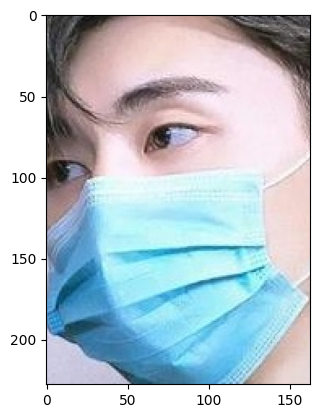

In [18]:
### Displaying the Images
# displaying with mask image
img = mpimg.imread('data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()



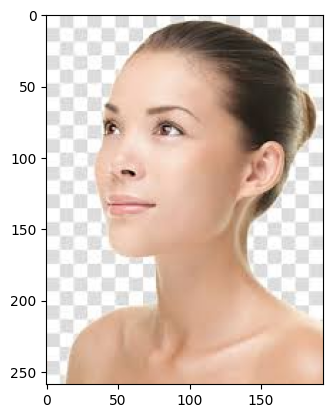

In [19]:
# displaying without mask image
img = mpimg.imread('data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [20]:
### Image Processing

## Resize the Images

## Convert the images to numpy arrays




In [21]:
# convert images to numpy arrays+

with_mask_path = 'data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = 'data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [22]:
type(data)

list

In [23]:
len(data)

7553

In [24]:
data[0]

array([[[226, 213, 197],
        [226, 213, 197],
        [226, 213, 197],
        ...,
        [214, 201, 182],
        [214, 201, 182],
        [214, 201, 182]],

       [[226, 213, 197],
        [226, 213, 197],
        [226, 213, 197],
        ...,
        [214, 201, 182],
        [214, 201, 182],
        [214, 201, 182]],

       [[226, 213, 197],
        [226, 213, 197],
        [226, 213, 197],
        ...,
        [214, 201, 182],
        [214, 201, 182],
        [214, 201, 182]],

       ...,

       [[235, 225, 216],
        [235, 225, 216],
        [235, 225, 216],
        ...,
        [219, 206, 189],
        [219, 206, 189],
        [219, 206, 189]],

       [[235, 225, 216],
        [235, 225, 216],
        [235, 225, 216],
        ...,
        [219, 206, 189],
        [219, 206, 189],
        [219, 206, 189]],

       [[235, 225, 216],
        [235, 225, 216],
        [235, 225, 216],
        ...,
        [217, 204, 187],
        [217, 204, 187],
        [217, 204, 187]]

In [25]:
type(data[0])

numpy.ndarray

In [26]:
data[0].shape

(128, 128, 3)

In [27]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [28]:
type(X)

numpy.ndarray

In [29]:
type(Y)

numpy.ndarray

In [30]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [31]:
print(Y)

[1 1 1 ... 0 0 0]


In [32]:
##Train Test Split

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [34]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [35]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [36]:
X_train[0]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[219, 221, 233],
        [219, 221, 233],
        [218, 220, 232],
        ...,
        [243, 246, 255],
        [243, 246, 255],
        [243, 246, 255]],

       [[217, 219, 231],
        [217, 219, 231],
        [216, 218, 230],
        ...,
        [243, 246, 255],
        [243, 246, 255],
        [243, 246, 255]],

       [[216, 218, 230],
        [216, 218, 230],
        [215, 217, 229],
        ...,
        [243, 246, 255],
        [243, 246, 255],
        [243, 246, 255]]

In [37]:
X_train_scaled[0]

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       ...,

       [[0.85882353, 0.86666667, 0.91372549],
        [0.85882353, 0.86666667, 0.91372549],
        [0.85490196, 0

In [38]:
## Building a Convolutional Neural Networks (CNN)

In [39]:
import tensorflow as tf
from tensorflow import keras

In [40]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [42]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - acc: 0.7870 - loss: 0.5019 - val_acc: 0.8678 - val_loss: 0.3074
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - acc: 0.8786 - loss: 0.3029 - val_acc: 0.8843 - val_loss: 0.2684
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - acc: 0.9040 - loss: 0.2435 - val_acc: 0.8893 - val_loss: 0.2914
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - acc: 0.9141 - loss: 0.2032 - val_acc: 0.8975 - val_loss: 0.2900
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - acc: 0.9261 - loss: 0.1974 - val_acc: 0.9041 - val_loss: 0.2436


In [43]:
### Model Evaluation

In [44]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9252 - loss: 0.1992
Test Accuracy = 0.9252150654792786


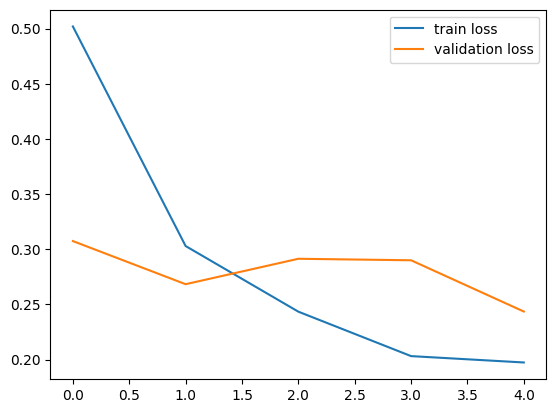

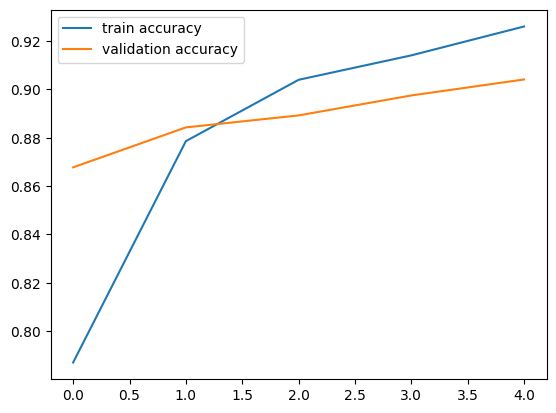

In [45]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

In [46]:
#### Predictive System

Path of the image to be predicted:  /Users/harshitdubey/Downloads/cheerful-indian-businessman-smiling-closeup-portrait-jobs-career-campaign.jpg


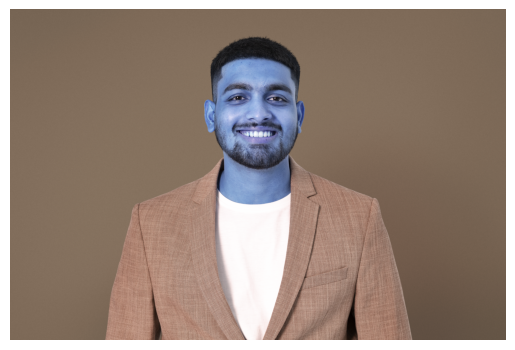

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.5223261  0.44984838]]
0
The person in the image is not wearing a mask


In [48]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.axis('off')
plt.show()

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted:  /Users/harshitdubey/Downloads/mask_image.jpg


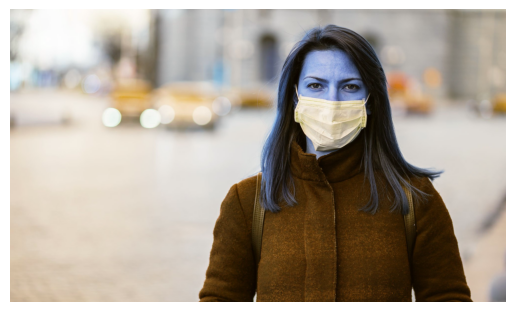

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[0.23649299 0.65198797]]
1
The person in the image is wearing a mask


In [51]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.axis('off')
plt.show()

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')